# MC no treinamento de NN

In [1]:
MC_simulation_samples = 1000
n_models_ensemble = 1
alpha = 0.05

dataset_name_list = ["train", "test"]

valor_max_list = [10]*2
valor_min_list = [0]*2
num_amostras_list = [100, 1]

erro_sistematico_x_list = [0.0]*2
erro_aleatorio_x_list = [0.2]*2
dist_erro_x_list = ["uniforme_absoluto"]*2

erro_sistematico_y_list = [0]*2
erro_aleatorio_y_list = [0]*2
dist_erro_y_list = ["uniforme_absoluto"]*2

gerar_mc_list = [True, True]

## Ambiente Básico

#### Imports

In [2]:
import torch
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import matplotlib.pyplot as plt

import time
import optuna

import tqdm

from modelo_scr.utils import *

from modelo_scr.modelo_pacheco import *
from modelo_scr.nn_ensamble import *
from modelo_scr.rf_ensamble import *
from modelo_scr.conformal_prediction import *

from sklearn.metrics import mean_absolute_error

#### Modelo do sistema simuado

In [3]:
def modelo(x):
    return 10*x**2

#### Gera os dataset

In [4]:
dataset = {}

for i in range(len(dataset_name_list)):
    print(f"Gerando dataset {dataset_name_list[i]}:")
    dataset[dataset_name_list[i]] = Dataset(modelo, 
                                            valor_max_list[i], 
                                            valor_min_list[i], 
                                            num_amostras_list[i],
                                            erro_sistematico_x_list[i], 
                                            erro_aleatorio_x_list[i], 
                                            dist_erro_x_list[i], 
                                            erro_sistematico_y_list[i], 
                                            erro_aleatorio_y_list[i], 
                                            dist_erro_y_list[i])
    if gerar_mc_list[i]:
        dataset[dataset_name_list[i]].gerar_monte_carlo(MC_simulation_samples)


Gerando dataset train:
Shape X_measured: (100,)
Shape y_measured: (100,)
Shape X_measured_mc: (100000,)
Shape y_measured_mc: (100000,)
Gerando dataset test:
Shape X_measured: (1,)
Shape y_measured: (1,)
Shape X_measured_mc: (1000,)
Shape y_measured_mc: (1000,)


#### Configura a NN

In [5]:
# Definição do modelo
def model_fn():
    return MLP(input_dim=1, hidden_layers=[72]*2, activation="relu", dropout=0.0)

# Configuração
config = TrainerConfig(epochs=500, lr=1e-3, device=None)

Usando dispositivo: cuda


## Treinamento da NN Ensable

In [6]:
model_dict = {}

### Modelo treinado com train dataset

In [7]:
model_dict['Train DS'] = NNEnsambleModel(model_fn,
                                        config,
                                        n_models=n_models_ensemble,
                                        verbose=True)

model_dict['Train DS'].fit(dataset["train"].X_measured.reshape((-1, 1)).numpy(), 
                            dataset["train"].y_measured.numpy())

Treinando ensemble de inferência do valor...


100%|██████████| 1/1 [00:01<00:00,  1.39s/it]

Treinamento concluído em 1.40s


### Modelo treinado com MC do train dataset

In [8]:
model_dict['MC Train'] = NNEnsambleModel(model_fn,
                                        config,
                                        n_models=n_models_ensemble,
                                        verbose=True)

model_dict['MC Train'].fit(dataset["train"].X_measured_mc.reshape((-1, 1)).numpy(), 
                        dataset["train"].y_measured_mc.numpy(), 
                        ds_size=None)

Treinando ensemble de inferência do valor...


100%|██████████| 1/1 [00:02<00:00,  2.24s/it]

Treinamento concluído em 2.25s


## Modelos de Estimativa

Avaliando modelo Train DS:
Inferência em 0.0011s
Avaliando modelo MC Train:
Inferência em 0.0005s


/tmp/ipykernel_25777/1534683404.py:19: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  print(f'Train: Media {np.mean(list(y_pred_dict["Train DS"]))}, Moda {np.argmax(np.bincount(list(y_pred_dict["Train DS"])))}')
/tmp/ipykernel_25777/1534683404.py:24: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  print(f'MC Train: Media {np.mean(list(y_pred_dict["MC Train"]))}, Moda {np.argmax(np.bincount(list(y_pred_dict["MC Train"])))}')
/tmp/ipykernel_25777/1534683404.py:29: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  print(f'Calculated: Media {np.mean(list(dataset["test"].y_calc_mc.numpy()))}, Moda {np.argmax(np.bincount(list(dataset["test"].y_calc_mc.numpy())))}')


Train: Media 983.3225708007812, Moda 993
MC Train: Media 981.257568359375, Moda 992
Calculated: Media 1010.1275024414062, Moda 994


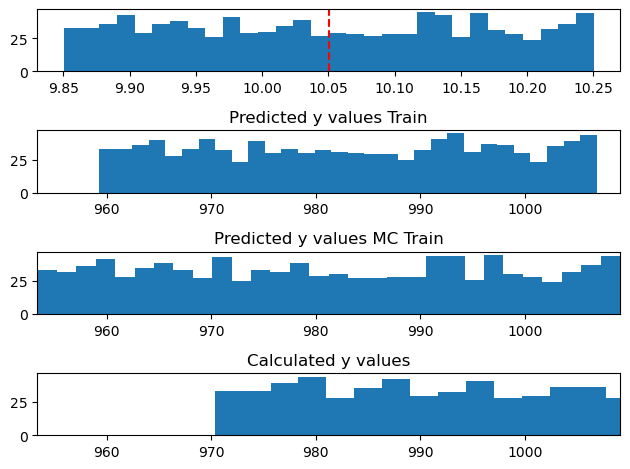

In [9]:
y_pred_dict = {}
for name, model in model_dict.items():
    print(f"Avaliando modelo {name}:")
    y_pred_dict[name], std = model.predict(dataset["test"].X_measured_mc.reshape((-1, 1)).numpy())


plt.subplot(4, 1, 1)
plt.hist(list(dataset["test"].X_measured_mc.numpy()), bins=30, label="X_MC")
plt.axvline(x=dataset["test"].X_measured.numpy(), color='red', linestyle='--', label='Measured X')

x_max = max([max(dataset["test"].y_measured_mc.numpy()), max(list(y_pred_dict['Train DS'])), max(list(y_pred_dict['MC Train']))])
x_min = min([min(dataset["test"].y_measured_mc.numpy()), min(list(y_pred_dict['Train DS'])), min(list(y_pred_dict['MC Train']))])


plt.subplot(4, 1, 2)
plt.hist(list(y_pred_dict['Train DS']), bins=30, label='Train DS')
plt.title("Predicted y values Train")
plt.xlim(x_min, x_max)
print(f'Train: Media {np.mean(list(y_pred_dict["Train DS"]))}, Moda {np.argmax(np.bincount(list(y_pred_dict["Train DS"])))}')
plt.subplot(4, 1, 3)
plt.hist(list(y_pred_dict['MC Train']), bins=30, label='MC Train')
plt.title("Predicted y values MC Train")
plt.xlim(x_min, x_max)
print(f'MC Train: Media {np.mean(list(y_pred_dict["MC Train"]))}, Moda {np.argmax(np.bincount(list(y_pred_dict["MC Train"])))}')
plt.subplot(4, 1, 4)
plt.hist(list(dataset["test"].y_calc_mc.numpy()), bins=30, label="y_test")
plt.title("Calculated y values")
plt.xlim(x_min, x_max)
print(f'Calculated: Media {np.mean(list(dataset["test"].y_calc_mc.numpy()))}, Moda {np.argmax(np.bincount(list(dataset["test"].y_calc_mc.numpy())))}')
#
# plt.legend()
plt.tight_layout()
plt.show()
